In [2]:
import pandas as pd
import numpy as np

# Configuración de reproducibilidad
np.random.seed(42)

def generar_datos(n=100):
    # Definimos la población (100 estudiantes)
    grupos = ['Deportista', 'Sedentario']
    
    data = {
        'id_estudiante': range(1, n + 1),
        'habito_actividad': np.random.choice(grupos, size=n, p=[0.4, 0.6]),
        'puntuacion_estres': np.random.randint(1, 11, size=n)
    }
    
    df = pd.DataFrame(data)
    
    # Generamos las horas de sueño basadas en el grupo (Inferencia inicial)
    # Los deportistas duermen un poco más en nuestra simulación
    def simular_sueno(row):
        if row['habito_actividad'] == 'Deportista':
            return np.random.normal(7.5, 0.8)
        else:
            return np.random.normal(6.5, 1.2)
            
    df['horas_sueno'] = df.apply(simular_sueno, axis=1).round(1)
    
    return df

if __name__ == "__main__":
    df_estudiantes = generar_datos()
    print("--- Dataset Generado para la Lección 1 ---")
    print(df_estudiantes.head(10))
    
    # Guardamos el dataset inicial como pide el entregable
    df_estudiantes.to_csv('dataset_estudiantes.csv', index=False)
    print("\nArchivo 'dataset_estudiantes.csv' guardado con éxito.")

--- Dataset Generado para la Lección 1 ---
   id_estudiante habito_actividad  puntuacion_estres  horas_sueno
0              1       Deportista                  7          7.7
1              2       Sedentario                  1          4.8
2              3       Sedentario                  4          5.3
3              4       Sedentario                  4          7.4
4              5       Deportista                  5          6.1
5              6       Deportista                  7          7.6
6              7       Deportista                  7          8.3
7              8       Sedentario                  4          6.7
8              9       Sedentario                  7          5.8
9             10       Sedentario                  3          5.5

Archivo 'dataset_estudiantes.csv' guardado con éxito.


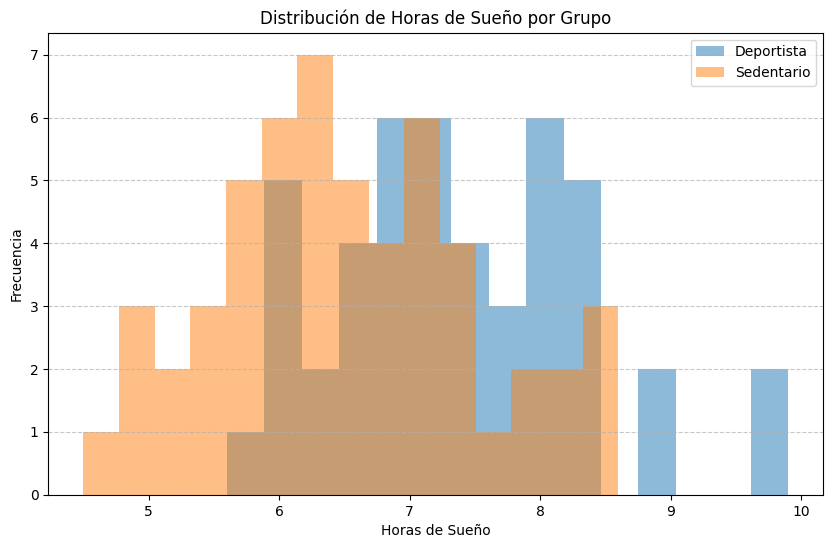

Imagen guardada


<Figure size 800x600 with 0 Axes>

In [18]:
import seaborn as sns # Si no lo tienes, pip install seaborn ayuda mucho
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for grupo in df_estudiantes['habito_actividad'].unique():
    subset = df_estudiantes[df_estudiantes['habito_actividad'] == grupo]
    plt.hist(subset['horas_sueno'], alpha=0.5, label=grupo, bins=15)

plt.title('Distribución de Horas de Sueño por Grupo')
plt.xlabel('Horas de Sueño')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
# Ejemplo para el gráfico de Intervalos de Confianza
plt.figure(figsize=(8, 6))
# ... (aquí va tu código de graficación anterior) ...

# GUARDAR LA IMAGEN
# 'bbox_inches' evita que se corten las etiquetas de los ejes
plt.savefig('grafico_inferencia_sueno1.png', dpi=300, bbox_inches='tight')
print("Imagen guardada")
plt.show()

In [3]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


--- Análisis de Probabilidad (Lección 3) ---
Media (μ): 6.91 | Desviación Estándar (σ): 1.07
Probabilidad de dormir menos de 6 horas: 19.68%


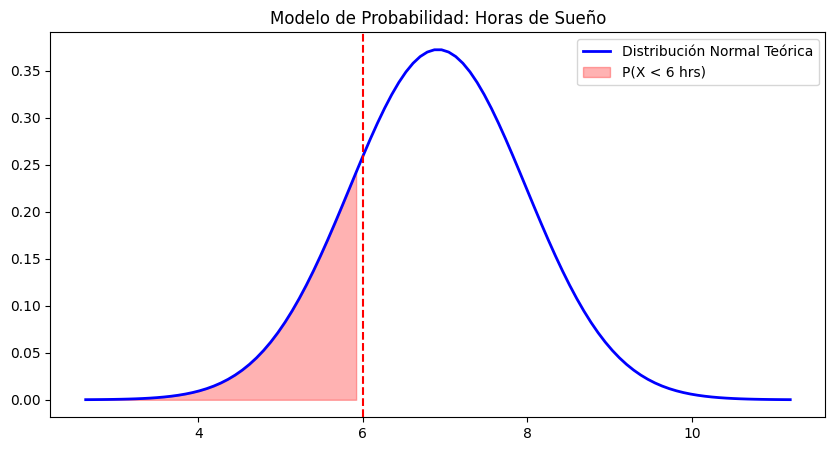

Imagen guardada como 'grafico_inferencia_sueno.png'


<Figure size 800x600 with 0 Axes>

In [13]:
from scipy.stats import norm

# Calculamos los parámetros generales de la población de la muestra
mu = df_estudiantes['horas_sueno'].mean()
sigma = df_estudiantes['horas_sueno'].std()

# 1. Definimos el valor límite (6 horas)
limite_sueno = 6

# 2. Calculamos la probabilidad usando la Función de Distribución Acumulada (CDF)
probabilidad_menos_6 = norm.cdf(limite_sueno, mu, sigma)

print(f"--- Análisis de Probabilidad (Lección 3) ---")
print(f"Media (μ): {mu:.2f} | Desviación Estándar (σ): {sigma:.2f}")
print(f"Probabilidad de dormir menos de 6 horas: {probabilidad_menos_6:.2%}")

# Visualización de la probabilidad en la curva
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 5))
plt.plot(x, y, 'b', lw=2, label='Distribución Normal Teórica')
plt.fill_between(x, y, where=(x <= limite_sueno), color='red', alpha=0.3, label='P(X < 6 hrs)')
plt.title('Modelo de Probabilidad: Horas de Sueño')
plt.axvline(limite_sueno, color='red', linestyle='--')
plt.legend()
plt.show()
# Ejemplo para el gráfico de Intervalos de Confianza
plt.figure(figsize=(8, 6))
# ... (aquí va tu código de graficación anterior) ...

# GUARDAR LA IMAGEN
# 'bbox_inches' evita que se corten las etiquetas de los ejes
plt.savefig('grafico_inferencia_sueno.png', dpi=300, bbox_inches='tight')
print("Imagen guardada como 'grafico_inferencia_sueno.png'")
plt.show()

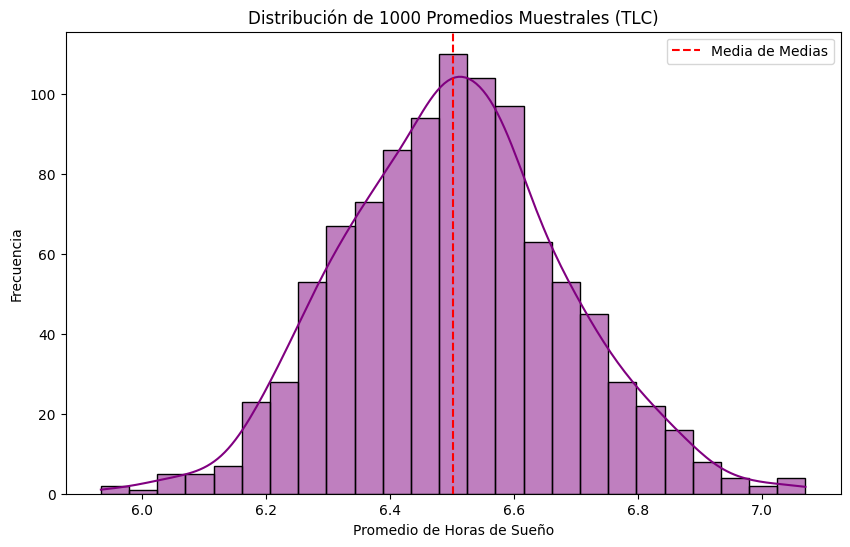

Imagen guardada como 'grafico_inferencia_sueno.png'


<Figure size 800x600 with 0 Axes>

Media de la población original: 6.50
Media de la distribución de promedios: 6.50


In [16]:
# 1. Filtramos los datos de un grupo (ej. Sedentarios)
datos_sedentarios = df_estudiantes[df_estudiantes['habito_actividad'] == 'Sedentario']['horas_sueno']

# 2. Simulación: Tomaremos 1000 muestras de tamaño n=30
n_muestras = 1000
tamano_muestra = 30
promedios_muestrales = []

for _ in range(n_muestras):
    muestra = np.random.choice(datos_sedentarios, size=tamano_muestra, replace=True)
    promedios_muestrales.append(muestra.mean())

# 3. Graficamos la Distribución de los Promedios
plt.figure(figsize=(10, 6))
sns.histplot(promedios_muestrales, kde=True, color='purple')
plt.title(f'Distribución de {n_muestras} Promedios Muestrales (TLC)')
plt.xlabel('Promedio de Horas de Sueño')
plt.ylabel('Frecuencia')

# Marcamos la media de los promedios
plt.axvline(np.mean(promedios_muestrales), color='red', linestyle='--', label='Media de Medias')
plt.legend()
plt.show()
# Ejemplo para el gráfico de Intervalos de Confianza
plt.figure(figsize=(8, 6))
# ... (aquí va tu código de graficación anterior) ...

# GUARDAR LA IMAGEN
# 'bbox_inches' evita que se corten las etiquetas de los ejes
plt.savefig('grafico_inferencia_sueno.png', dpi=300, bbox_inches='tight')
print("Imagen guardada como 'grafico_inferencia_sueno.png'")
plt.show()

print(f"Media de la población original: {datos_sedentarios.mean():.2f}")
print(f"Media de la distribución de promedios: {np.mean(promedios_muestrales):.2f}")

In [7]:
import scipy.stats as stats

--- Intervalos de Confianza al 95% ---

Grupo Deportista:
  Media Muestral: 7.40 hrs
  Rango: [7.11 - 7.68] horas

Grupo Sedentario:
  Media Muestral: 6.50 hrs
  Rango: [6.23 - 6.77] horas


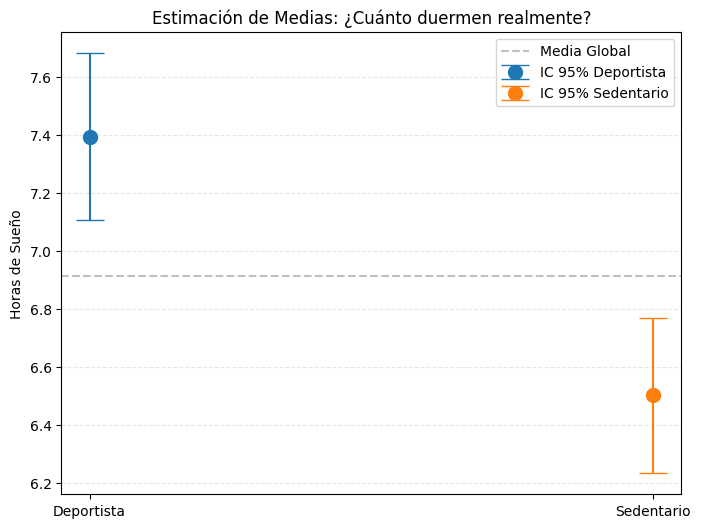

Imagen guardada como 'grafico_inferencia_sueno.png'


<Figure size 800x600 with 0 Axes>

In [11]:
import scipy.stats as stats
import matplotlib.pyplot as plt

def calcular_intervalo_confianza(data, confianza=0.95):
    n = len(data)
    media = np.mean(data)
    std_err = stats.sem(data)
    # Usamos t.interval para mayor precisión con muestras pequeñas
    intervalo = stats.t.interval(confianza, n-1, loc=media, scale=std_err)
    return intervalo

# 1. Calculamos los intervalos para cada grupo
grupos = df_estudiantes['habito_actividad'].unique()
resultados_ic = {}

for g in grupos:
    datos_g = df_estudiantes[df_estudiantes['habito_actividad'] == g]['horas_sueno']
    ic = calcular_intervalo_confianza(datos_g)
    resultados_ic[g] = {'media': datos_g.mean(), 'ic_inf': ic[0], 'ic_sup': ic[1]}

# 2. Mostramos los resultados (Cambiado de :2d a :2f)
print("--- Intervalos de Confianza al 95% ---")
for g, v in resultados_ic.items():
    print(f"\nGrupo {g}:")
    print(f"  Media Muestral: {v['media']:.2f} hrs")
    print(f"  Rango: [{v['ic_inf']:.2f} - {v['ic_sup']:.2f}] horas")

# 3. Gráfico de comparación
plt.figure(figsize=(8, 6))
for i, (g, v) in enumerate(resultados_ic.items()):
    plt.errorbar(g, v['media'], yerr=[[v['media']-v['ic_inf']], [v['ic_sup']-v['media']]], 
                 fmt='o', capsize=10, markersize=10, label=f'IC 95% {g}')

plt.axhline(df_estudiantes['horas_sueno'].mean(), color='gray', linestyle='--', alpha=0.5, label='Media Global')
plt.title('Estimación de Medias: ¿Cuánto duermen realmente?')
plt.ylabel('Horas de Sueño')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()
# Ejemplo para el gráfico de Intervalos de Confianza
plt.figure(figsize=(8, 6))
# ... (aquí va tu código de graficación anterior) ...

# GUARDAR LA IMAGEN
# 'bbox_inches' evita que se corten las etiquetas de los ejes
plt.savefig('grafico_inferencia_sueno.png', dpi=300, bbox_inches='tight')
print("Imagen guardada como 'grafico_inferencia_sueno.png'")
plt.show()

In [10]:
# Prueba t de Student para muestras independientes (Welch t-test)
deportistas = df_estudiantes[df_estudiantes['habito_actividad'] == 'Deportista']['horas_sueno']
sedentarios = df_estudiantes[df_estudiantes['habito_actividad'] == 'Sedentario']['horas_sueno']

t_stat, p_val = stats.ttest_ind(deportistas, sedentarios, equal_var=False)

print("--- CONCLUSIÓN ESTADÍSTICA FINAL ---")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_val:.10f}")

alpha = 0.05
if p_val < alpha:
    print("\nRESULTADO: Rechazamos la Hipótesis Nula (H0).")
    print("Conclusión: Existe una diferencia estadísticamente significativa. Los estudiantes deportistas duermen más.")
else:
    print("\nRESULTADO: No se puede rechazar la Hipótesis Nula (H0).")
    print("Conclusión: No hay evidencia suficiente para decir que el hábito físico afecte el sueño.")

--- CONCLUSIÓN ESTADÍSTICA FINAL ---
Estadístico t: 4.5645
Valor p: 0.0000148390

RESULTADO: Rechazamos la Hipótesis Nula (H0).
Conclusión: Existe una diferencia estadísticamente significativa. Los estudiantes deportistas duermen más.


In [15]:
# Definimos la información del diccionario
diccionario_data = {
    'Variable': ['id_estudiante', 'habito_actividad', 'horas_sueno', 'puntuacion_estres'],
    'Tipo': ['Cuantitativa Discreta', 'Cualitativa Nominal', 'Cuantitativa Continua', 'Cuantitativa Discreta'],
    'Descripción': [
        'Identificador único del alumno.',
        'Categoría del estudiante: Deportista o Sedentario.',
        'Promedio de horas de descanso diario reportadas.',
        'Nivel de estrés percibido en escala de 1 a 10.'
    ],
    'Unidad de Medida': ['N/A', 'N/A', 'Horas', 'Puntos']
}

df_diccionario = pd.DataFrame(diccionario_data)

# Guardar como archivo para el entregable
df_diccionario.to_csv('diccionario_variables.csv', index=False)

print("--- Diccionario de Variables ---")
display(df_diccionario)

--- Diccionario de Variables ---


,Variable,Tipo,Descripción,Unidad de Medida
0,id_estudiante,Cuantitativa Discreta,Identificador único del alumno.,N/A
1,habito_actividad,Cualitativa Nominal,Categoría del estudiante: Deportista o Sedenta...,N/A
2,horas_sueno,Cuantitativa Continua,Promedio de horas de descanso diario reportadas.,Horas
3,puntuacion_estres,Cuantitativa Discreta,Nivel de estrés percibido en escala de 1 a 10.,Puntos
